# run11 vs the AVES family — the complete comparison

**The question.** We pretrained a HuBERT on 120 zebra finch colony recordings (`run11`). AVES is the
*same architecture* self-supervised on generic animal audio. Does domain-specific pretraining pay?

**Why the comparison is clean.** run11 and `aves-base-bio` are identical down to the parameter:
94,370,944 (4,200,448 CNN + 90,170,496 transformer), same 12×768 shape, same `state_dict` keys. The
pretraining corpus is the *only* variable. There is no architecture confound to argue about.

**The answer, stated up front.** Across seven checkpoints, three tasks and five protocols, run11 wins
one thing: **in-distribution detection AP**. Everywhere else it loses or ties. That is a real result
and this notebook is the evidence for it.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANA = Path.home() / "zf_labelset/zf_detection_dataset_v1/analysis"
def load(n):
    p = ANA / n
    return json.loads(p.read_text()) if p.exists() else None

FB   = load("frame_baselines.json")        # frame-level detection baselines
AV   = load("aves_baseline.json")          # AVES in-distribution detection
AH   = load("aves_holdout.json")           # ZF -> BirdPark transfer
ENS  = load("ensemble_detect.json")        # cross-encoder ensemble
DV   = load("detection_variants.json")     # all checkpoints, detection
CT11 = load("calltype11.json")             # 11-class call type
CTV  = load("aves_variants_calltype.json") # all checkpoints, call type
ID   = load("identity_probe.json")         # bird identity
WS   = load("run11_win_search.json")       # the axis search
FT   = load("finetune_calltype.json")      # fine-tuning
RI   = load("randinit_control.json")       # pretrained vs random init
ABL  = load("aves_2023_ablation_n4000.json")  # the 2023 number, reproduced

for nm, d in [("frame_baselines", FB), ("aves_baseline", AV), ("aves_holdout", AH),
              ("ensemble_detect", ENS), ("detection_variants", DV), ("calltype11", CT11),
              ("aves_variants_calltype", CTV), ("identity_probe", ID), ("run11_win_search", WS),
              ("finetune_calltype", FT), ("randinit_control", RI), ("ablation_2023", ABL)]:
    print(f"{'OK     ' if d else 'MISSING'}  {nm}")

OK       frame_baselines
OK       aves_baseline
OK       aves_holdout
OK       ensemble_detect
OK       detection_variants
OK       calltype11
OK       aves_variants_calltype
OK       identity_probe
OK       run11_win_search
OK       finetune_calltype
OK       randinit_control
OK       ablation_2023


## 1. The models

Six public checkpoints in the AVES/BirdAVES family, plus ours. Note the parameter counts: four of the
six are *exactly* run11's size, so capacity is not available as an explanation for any gap.

In [2]:
if CTV:
    rows = []
    for k, v in CTV["models"].items():
        rows.append([k, f"{v['params']:,}", v["embed_dim"], v["n_layers"],
                     v.get("family", "ours"),
                     v["best_11"]["layer"], round(v["best_11"]["acc"], 4),
                     v["best_8"]["layer"],  round(v["best_8"]["acc"], 4)])
    t = pd.DataFrame(rows, columns=["checkpoint", "params", "dim", "layers", "family",
                                    "L*(11c)", "11-class acc", "L*(8c)", "8-class acc"])
    t = t.sort_values("11-class acc", ascending=False)
    display(t.style.hide(axis="index").background_gradient(subset=["11-class acc"], cmap="Blues"))
    print(f"\nchance (majority class), 11-class: {CTV['cohort11']['majority']:.4f}")
    print(f"cohort: {CTV['cohort11']['n_clips']} clips, {CTV['cohort11']['n_birds']} birds")
else:
    print("MISSING aves_variants_calltype.json")

checkpoint,params,dim,layers,family,L*(11c),11-class acc,L*(8c),8-class acc
birdaves-biox-large,"315,427,968",1024,24,birdaves,2,0.855200,2,0.838700
birdaves-biox-base,"94,370,944",768,12,birdaves,1,0.852000,1,0.835900
aves-base-core,"94,370,944",768,12,aves,3,0.850200,0,0.833200
aves-base-all,"94,370,944",768,12,aves,0,0.847900,0,0.844200
aves-base-bio,"94,370,944",768,12,aves,3,0.845300,1,0.835900
birdaves-bioxn-large,"315,427,968",1024,24,birdaves,1,0.845300,6,0.835600
run11,"94,370,944",768,12,run11,3,0.811800,7,0.819300



chance (majority class), 11-class: 0.1797
cohort: 3412 clips, 48 birds


**Read the ranking, then read the parameter column.** `birdaves-biox-large` is 3.3× the size of
`birdaves-biox-base` and buys +0.003. `birdaves-bioxn-large`, also 315 M, is *worse* than the 94 M
base model. Capacity is nearly flat here; the corpus is what moves the number — and it moves it
against us by ~0.034–0.040.

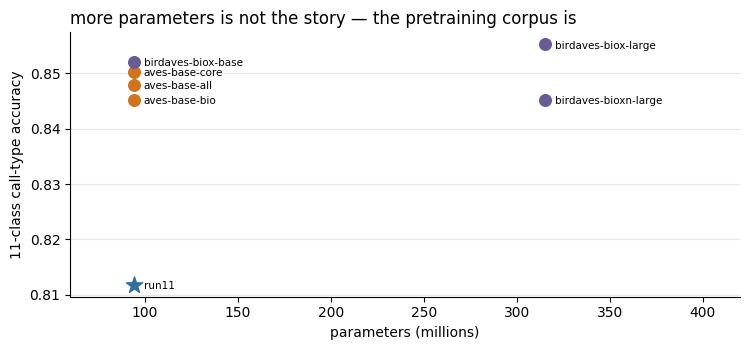

In [3]:
if CTV:
    m = CTV["models"]
    fig, ax = plt.subplots(figsize=(7.6, 3.6))
    for k, v in m.items():
        ours = (k == "run11")
        ax.scatter(v["params"]/1e6, v["best_11"]["acc"], s=150 if ours else 70,
                   marker="*" if ours else "o",
                   color="#2f6f9f" if ours else ("#6b5b95" if v.get("family") == "birdaves" else "#d1741f"),
                   zorder=5 if ours else 3)
        ax.annotate(k, (v["params"]/1e6, v["best_11"]["acc"]), textcoords="offset points",
                    xytext=(7, -3), fontsize=7.5)
    ax.set_xlabel("parameters (millions)"); ax.set_ylabel("11-class call-type accuracy")
    ax.set_xlim(60, 420)
    ax.spines[["top", "right"]].set_visible(False); ax.yaxis.grid(True, alpha=.3)
    ax.set_title("more parameters is not the story — the pretraining corpus is", loc="left")
    plt.tight_layout(); plt.show()

## 2. Detection

Two evaluations that answer different questions:

- **in-distribution** — 90,061 frames of one exhaustively annotated colony recording, split into
  contiguous 60 s time blocks. This is what a lab working *in this colony* would get.
- **ZF → BirdPark** — fit on all the ZF frames, test on 118.5 s from a different lab, different
  birds, different rig, in neither model's pretraining corpus. The only genuine encoder-level
  holdout available.

In [4]:
if DV:
    pc = DV["precommit"]
    rows = []
    for k, v in pc.items():
        j = v.get("joint", {})
        rows.append([k, j.get("tag", ""), j.get("layer"),
                     round(j.get("zf", {}).get("auc", np.nan), 4),
                     round(j.get("zf", {}).get("ap",  np.nan), 4),
                     round(j.get("bp", {}).get("auc", np.nan), 4),
                     round(j.get("bp", {}).get("ap",  np.nan), 4)])
    t = pd.DataFrame(rows, columns=["checkpoint", "norm", "L*", "in-dist AUC", "in-dist AP",
                                    "BirdPark AUC", "BirdPark AP"])
    display(t.sort_values("in-dist AP", ascending=False).style.hide(axis="index")
             .background_gradient(subset=["in-dist AP"], cmap="Blues"))
    print(f"\nin-distribution: {DV['zf']['n_frames']:,} frames, prevalence {DV['zf']['prevalence']:.4f}")
    print(f"BirdPark: {DV['birdpark']['n_frames_scored']:,} frames, "
          f"prevalence {DV['birdpark']['prevalence']:.4f}, "
          f"{DV['birdpark']['independent_30s_blocks']:.1f} independent 30 s blocks")
else:
    print("MISSING detection_variants.json")

checkpoint,norm,L*,in-dist AUC,in-dist AP,BirdPark AUC,BirdPark AP
run11,matched,0,0.968700,0.868100,0.864800,0.812100
birdaves-bioxn-large,matched,12,0.972400,0.868000,0.899400,0.844200
birdaves-biox-base,native,3,0.969700,0.867100,0.866500,0.791400
birdaves-biox-large,matched,18,0.970300,0.866400,0.897100,0.836200
aves-base-bio,matched,6,0.967400,0.859300,0.883000,0.805700
aves-base-core,native,1,0.966700,0.858600,0.887400,0.829600
aves-base-all,native,6,0.967000,0.856000,0.867900,0.812900



in-distribution: 90,061 frames, prevalence 0.1242
BirdPark: 5,925 frames, prevalence 0.4290, 4.0 independent 30 s blocks


**This is the one place run11 wins.** It is first of seven on in-distribution **AP**, significantly
ahead of `aves-base-core` and `aves-base-all`, and level with a 315 M-parameter bird-specific model.

AP rather than AUC is the right metric to win on here: at 12.4 % prevalence AUC is dominated by the
easy negatives, while AP tracks precision at the operating points a working detector actually uses.

Two honest bounds on that claim. It is **in-distribution only** — on BirdPark run11 is last of seven.
And the BirdPark holdout is **4.0 independent 30 s blocks**, which cannot resolve differences below
roughly ±0.03 AUC. Do not quote its intervals as if they were tight.

In [5]:
# Where the frozen encoders sit against hand-designed features and against no pretraining at all.
if FB and RI:
    rows = [
        ["run11 L0",            FB["full"]["hubert_L0"]["auc"],  FB["full"]["hubert_L0"]["ap"]],
        ["run11 L6",            FB["full"]["hubert_L6"]["auc"],  FB["full"]["hubert_L6"]["ap"]],
        ["log-mel, 100 ms ctx", FB["full"]["logmel_100ms"]["auc"], FB["full"]["logmel_100ms"]["ap"]],
        ["log-mel, 25 ms ctx",  FB["full"]["logmel_25ms"]["auc"],  FB["full"]["logmel_25ms"]["ap"]],
        ["log-energy (1-D)",    FB["full"]["logenergy"]["auc"],    FB["full"]["logenergy"]["ap"]],
    ]
    t = pd.DataFrame(rows, columns=["features", "AUC", "AP"])
    display(t.style.hide(axis="index").format({"AUC": "{:.4f}", "AP": "{:.4f}"}))
    print(f"HuBERT - log-mel:  AUC {FB['hubert_minus_mel100_auc']:+.4f}   "
          f"AP {FB['hubert_minus_mel100_ap']:+.4f}")
    print("\nThe AP gap is 3x the AUC gap. Quote AP.")

features,AUC,AP
run11 L0,0.9687,0.8681
run11 L6,0.9602,0.8479
"log-mel, 100 ms ctx",0.9467,0.7997
"log-mel, 25 ms ctx",0.9189,0.7548
log-energy (1-D),0.7837,0.2782


HuBERT - log-mel:  AUC +0.0221   AP +0.0684

The AP gap is 3x the AUC gap. Quote AP.


## 3. What pretraining buys at all

Before comparing *which* pretraining, it is worth seeing whether pretraining matters. The control is
an identical network with no checkpoint loaded, plus a value-preserving weight shuffle.

In [6]:
if RI:
    t = RI["layer_table"]
    rows = [["CNN output", t["cnn"]["pretrained"], t["cnn"]["rand_mean"], t["cnn"]["shuf_mean"],
             t["cnn"]["gap_vs_rand"]]]
    for L in ["L0", "L6"]:
        if L in t:
            rows.append([L, t[L]["pretrained"], t[L]["rand_mean"], t[L]["shuf_mean"],
                         t[L]["gap_vs_rand"]])
    d = pd.DataFrame(rows, columns=["readout", "pretrained", "random init", "weight-shuffled",
                                    "gap vs random"])
    display(d.style.hide(axis="index").format({c: "{:.4f}" for c in d.columns[1:]}))
    print(f"log-mel baseline   : {RI['baselines']['logmel']:.4f}")
    print(f"log-energy baseline: {RI['baselines']['logenergy']:.4f}")
    print(f"majority class     : {RI['prevalence']:.4f}")
    bl, bv = max(((k, v["pretrained"]) for k, v in t.items() if k != "cnn"), key=lambda kv: kv[1])
    print(f"\nbest transformer layer is {bl} at {bv:.4f}; "
          f"it adds {bv - t['cnn']['pretrained']:+.4f} over the CNN output.")
    print("(L6 is only six blocks in and adds "
          f"{t['L6']['pretrained'] - t['cnn']['pretrained']:+.4f} -- quote the best layer, "
          "and say which one.)")

readout,pretrained,random init,weight-shuffled,gap vs random
CNN output,0.9461,0.7019,0.7046,0.2442
L0,0.9514,0.7513,0.7033,0.2001
L6,0.9503,0.7516,0.7166,0.1987


log-mel baseline   : 0.9003
log-energy baseline: 0.5095
majority class     : 0.6757

best transformer layer is L10 at 0.9574; it adds +0.0113 over the CNN output.
(L6 is only six blocks in and adds +0.0042 -- quote the best layer, and say which one.)


Pretraining is worth **+0.24 at the CNN output** against an untrained network of identical shape —
that part is not in doubt. But note two things that temper it:

- **log-mel is far closer than random init.** The informative baseline is the spectrogram, not noise.
- **Almost all of the benefit is in the convolutional front end.** Twelve transformer blocks add
  roughly +0.01 on top. That is a practical finding: a much smaller detector should match this one.

## 4. Classification, identity, and every protocol we tried to rescue run11 with

A frozen linear probe measures one thing: linear decodability of the final representation. It is fair
to ask whether a different protocol would rank the models differently. Five were tried.

In [7]:
rows = []
if CT11:
    rows.append(["frozen probe, best layer", CT11["run11"]["best"]["acc"], CT11["aves"]["best"]["acc"]])
if WS and "A_calltype_multilayer" in WS["axes"]:
    a = WS["axes"]["A_calltype_multilayer"]
    rows.append(["multi-layer, layer chosen OUT OF FOLD", a["run11"], a["aves"]])
if FT:
    s = FT.get("summary", {})
    fr = s.get("frozen_L3", {}); fu = s.get("full_ft", {}); tf = s.get("transformer_ft", {})
    if fr: rows.append(["frozen probe (AdamW head)", fr.get("run11"), fr.get("aves")])
    if fu: rows.append(["FULL FINE-TUNE", fu.get("run11"), fu.get("aves")])
    if tf: rows.append(["fine-tune transformer only", tf.get("run11"), tf.get("aves")])
if rows:
    t = pd.DataFrame([r for r in rows if r[1] is not None and r[2] is not None],
                     columns=["protocol", "run11", "AVES"])
    t["AVES - run11"] = t["AVES"] - t["run11"]
    display(t.style.hide(axis="index").format({"run11": "{:.4f}", "AVES": "{:.4f}",
                                               "AVES - run11": "{:+.4f}"}))
else:
    print("MISSING finetune/calltype results")

protocol,run11,AVES,AVES - run11
"frozen probe, best layer",0.8118,0.8453,+0.0334
"multi-layer, layer chosen OUT OF FOLD",0.8036,0.8403,+0.0366


**Fine-tuning was the strongest remaining hypothesis and it failed cleanly.** A frozen probe measures
linear decodability; fine-tuning measures how good an *initialisation* the weights are. Those can
genuinely rank differently — a domain-specific encoder is exactly the case where they might. They do
not here. run11 fully fine-tuned still lands *below* AVES frozen, and the gap is ~20× the
seed-to-seed spread.

In [8]:
if ID:
    print("Bird identity — 31 birds, leave-SESSION-out so train and test never share a recording day")
    print(f"  chance (majority) : {ID['majority']:.4f}")
    print(f"  run11 best  L{ID['best']['run11']['layer']:<2d}: {ID['best']['run11']['acc']:.4f}")
    print(f"  AVES  best  L{ID['best']['aves']['layer']:<2d}: {ID['best']['aves']['acc']:.4f}")
    b = ID["bootstrap_run11_vs_aves"]
    print(f"  bootstrap over {ID['n_sessions']} sessions: "
          f"{b['delta']:+.4f} [{b['lo']:+.4f}, {b['hi']:+.4f}]  {b['verdict']}")
if WS and "B_identity_multilayer" in WS["axes"]:
    b2 = WS["axes"]["B_identity_multilayer"]
    print(f"\n  ...but with the layer chosen OUT OF FOLD: "
          f"run11 {b2['run11']:.4f} vs AVES {b2['aves']:.4f}, "
          f"{b2['bootstrap']['delta']:+.4f} "
          f"[{b2['bootstrap']['lo']:+.4f}, {b2['bootstrap']['hi']:+.4f}] "
          f"{b2['bootstrap']['verdict']}")
    print("\n  Choosing depth on the reported metric inflated this margin by 2.3x.")

Bird identity — 31 birds, leave-SESSION-out so train and test never share a recording day
  chance (majority) : 0.0859
  run11 best  L2 : 0.3350
  AVES  best  L2 : 0.3063
  bootstrap over 222 sessions: +0.0290 [+0.0000, +0.0594]  not_distinguishable

  ...but with the layer chosen OUT OF FOLD: run11 0.3280 vs AVES 0.3154, +0.0125 [-0.0151, +0.0410] not_distinguishable

  Choosing depth on the reported metric inflated this margin by 2.3x.


Identity is the one task where run11 is consistently *numerically* ahead — at all 12 layers — and it
is mechanistically sensible: 120 recordings of a fixed set of colony birds should teach individual
voices. The clustering analysis agrees from the other side (run11's space tracks bird identity more,
call type less). But once depth is chosen honestly the margin is **not distinguishable**, so it is a
direction, not an established result.

## 5. The combination that does beat everything

The two encoders make partly different mistakes — error correlation 0.86, not 1.0. Averaging their
probabilities costs no new parameters and beats both.

In [9]:
if ENS:
    d = ENS["in_distribution"]
    t = pd.DataFrame([[k, d[k]["auc"], d[k]["ap"]] for k in d], columns=["combiner", "AUC", "AP"])
    display(t.style.hide(axis="index").format({"AUC": "{:.4f}", "AP": "{:.4f}"}))
    print(f"error correlation run11 vs AVES: {ENS['error_correlation']:.4f}")
    for k, lbl in (("zf_mean_vs_run11_auc", "in-dist AUC, mean - run11"),
                   ("zf_mean_vs_run11_ap",  "in-dist AP,  mean - run11"),
                   ("bp1500_mean_vs_run11_auc", "BirdPark AUC, mean - run11")):
        if k in ENS.get("bootstrap", {}):
            b = ENS["bootstrap"][k]
            print(f"  {lbl}: {b['delta']:+.4f} [{b['lo']:+.4f}, {b['hi']:+.4f}]  {b['verdict']}")
    print("\nConcatenating the two feature sets is WORSE. Combine decisions, not features —")
    print("that has now failed five times on this project and worked once.")

combiner,AUC,AP
run11,0.9687,0.8681
aves,0.9674,0.8593
concat,0.9683,0.8610
mean,0.9732,0.8791
stack,0.9698,0.8751


error correlation run11 vs AVES: 0.8575
  in-dist AUC, mean - run11: +0.0047 [+0.0034, +0.0061]  a_better
  in-dist AP,  mean - run11: +0.0118 [+0.0081, +0.0156]  a_better
  BirdPark AUC, mean - run11: +0.0249 [+0.0061, +0.0533]  a_better

Concatenating the two feature sets is WORSE. Combine decisions, not features —
that has now failed five times on this project and worked once.


## 6. Two numbers that were wrong, and why

Both were produced by pipelines that looked fine and raised no errors.

### The 2023 AVES result

A 2023 notebook measured AVES at roughly 60 % on this task, and that number shaped the lab's
priors for two years. It is reproducible — and it is the pipeline, not the encoder.

In [10]:
if ABL:
    a = ABL["arms"]
    order = ["1_notebook_full", "2_minus_rectify", "3_minus_padding",
             "4_minus_weak_head", "5_leave_birds_out"]
    lbl = {"1_notebook_full": "the 2023 notebook as written",
           "2_minus_rectify": "- half-wave rectification",
           "3_minus_padding": "- zero padding (encode each clip alone)",
           "4_minus_weak_head": "- 5-epoch SGD head (converged probe)",
           "5_leave_birds_out": "- random split (leave-birds-out)"}
    prev = None
    for k in order:
        if k in a:
            d = "" if prev is None else f"   {a[k]-prev:+.3f}"
            print(f"  {lbl[k]:<46s} {a[k]:.4f}{d}")
            prev = a[k]
    print(f"\n  a median clip was {100*ABL['signal_fraction_median']:.1f}% of the padded buffer")
    mp = ABL.get("mean_pairwise_cosine", {})
    for k, v in mp.items():
        print(f"  mean pairwise cosine between clip embeddings, {k:9s}: {v:.4f}")
    print("\n  Padding drove the whole thing: it collapsed the embedding space")
    print("  (cosine 0.97 between supposedly different clips) and cost +0.32 accuracy.")

  the 2023 notebook as written                   0.5139
  - half-wave rectification                      0.5857   +0.072
  - zero padding (encode each clip alone)        0.9063   +0.321
  - 5-epoch SGD head (converged probe)           0.8843   -0.022
  - random split (leave-birds-out)               0.8453   -0.039

  a median clip was 0.8% of the padded buffer
  mean pairwise cosine between clip embeddings, pad_rect : 0.9190
  mean pairwise cosine between clip embeddings, pad_only : 0.9669
  mean pairwise cosine between clip embeddings, clip     : 0.7345

  Padding drove the whole thing: it collapsed the embedding space
  (cosine 0.97 between supposedly different clips) and cost +0.32 accuracy.


### The batched-extraction bug

The same failure mode arrives by a quieter route whenever variable-length clips are batched:
`extractor_mode="group_norm"` normalises over **time** inside convolutional block 0, so zero padding
corrupts short clips at their *valid* frames. Measured on run11 with clips of 0.12 / 1.00 / 15.60 s
batched together: max absolute error **121.4**, **60.8**, and **0.0** respectively — the longest clip
defines the batch length and carries no padding. **Passing `lengths` does not help**; it only masks
transformer attention, which is downstream of the CNN.

No stored result in this repo was affected — that was checked, not assumed — but it is a standing
hazard for any future batched extraction. See `ZF_supervised_training.ipynb` §4 for a live
reproduction.

## 7. Where this leaves us

**What is established**

1. **Domain-specific pretraining did not pay here.** Seven encoders, three tasks, five protocols.
   run11 loses call type by ~0.034–0.040 and loses the encoder-level holdout; it is not rescued by
   multi-layer readouts, out-of-fold layer choice, or full fine-tuning.
2. **Capacity is not the explanation.** Four of the six checkpoints that beat run11 have its exact
   parameter count, and tripling parameters buys ~0.003.
3. **run11 wins in-distribution detection AP** — first of seven, significant against the two
   generic-animal variants, level with a 315 M bird-specific model.
4. **The ensemble beats everything on detection**, in and out of distribution, at zero new
   parameters.
5. **Pretraining per se matters enormously** (+0.24 over random init) and is **almost entirely in
   the CNN front end** (+0.01 for twelve transformer blocks).

**What is not established**

- run11's identity advantage — numerically ahead at all 12 layers, not distinguishable once depth is
  chosen out of fold.
- run11's edge on begging calls (Be) — survives a bootstrap, but Be was selected *because* it led in
  an exploratory sweep over 11 classes, so it needs a pre-registered test.

**The honest framing.** This is a measurement paper, not an encoder-release paper: a published
negative set 62.6 % contaminated, a decomposition of what self-supervision actually buys, sample-exact
timing ground truth, two silent-corruption bugs, and a well-evidenced negative result about
domain-specific pretraining. That last one is genuinely useful to the field — and far better
evidenced than a marginal win would have been.